# KNN

In [174]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

In [175]:
np.random.seed(1234)
X, y = make_blobs(n_samples=300, centers=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)

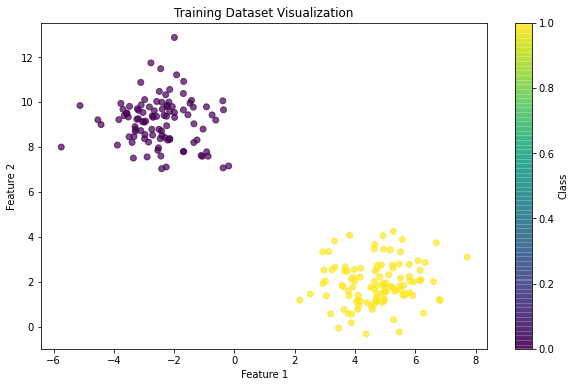

In [176]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.title('Training Dataset Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')
plt.show()

In [177]:
def plot_decision_boundary(X, y, model, title):
    h = 0.02  # Step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap='viridis', alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar(label='Class')
    plt.show()

In [186]:
%%time
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

Wall time: 4 ms


KNeighborsClassifier(n_neighbors=3)

In [187]:
plt.figure(figsize=(15, 10))

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

<Figure size 1080x720 with 0 Axes>

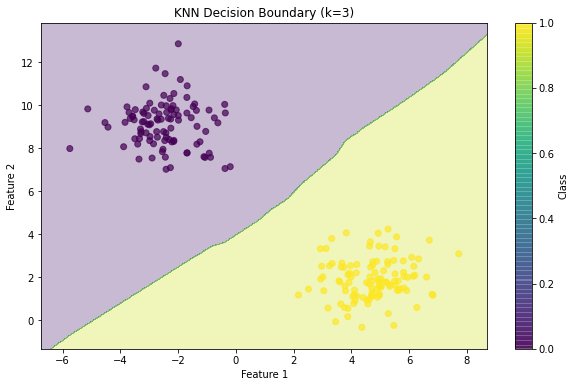

Wall time: 17.3 s


In [188]:
%%time
plot_decision_boundary(X_train, y_train, knn, f'KNN Decision Boundary (k={3})')

In [194]:
X, y = make_blobs(n_samples=300, centers=3, cluster_std=2.8, random_state=1234)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)

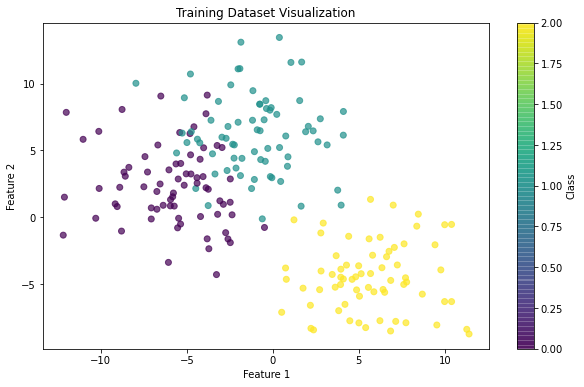

In [195]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.title('Training Dataset Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')
plt.show()

In [198]:
X, y = make_blobs(n_samples=300, centers=3, cluster_std=2.8, random_state=1234)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)

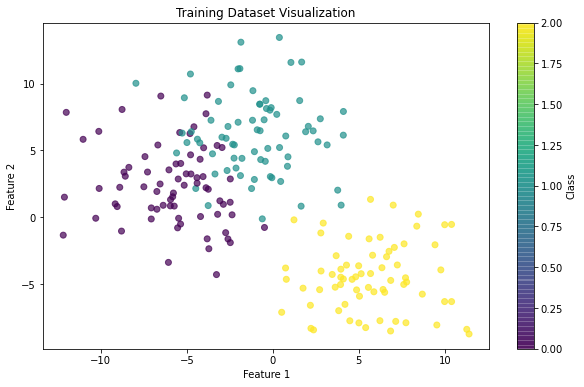

In [199]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.title('Training Dataset Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')
plt.show()

<Figure size 1080x720 with 0 Axes>

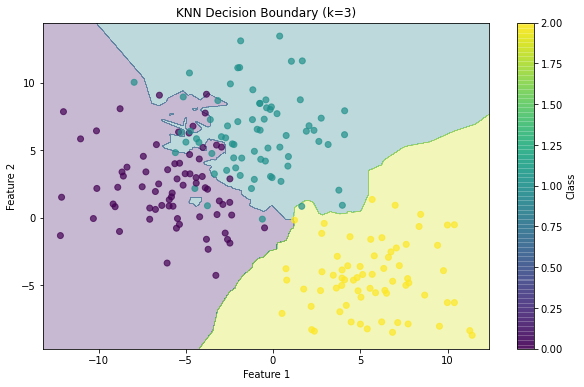

In [200]:
plt.figure(figsize=(15, 10))

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

plot_decision_boundary(X_train, y_train, knn, f'KNN Decision Boundary (k={3})')

<Figure size 1080x720 with 0 Axes>

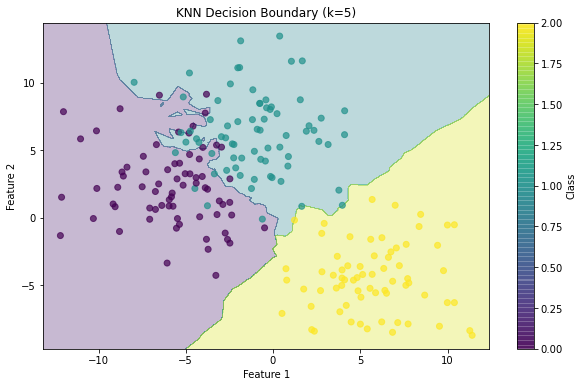

In [203]:
plt.figure(figsize=(15, 10))

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

plot_decision_boundary(X_train, y_train, knn, f'KNN Decision Boundary (k={5})')

In [134]:
k_range = range(1, 17, 2)
train_scores = []
test_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, knn.predict(X_train)))
    test_scores.append(accuracy_score(y_test, knn.predict(X_test)))

In [132]:
np.argmax(train_scores)

0

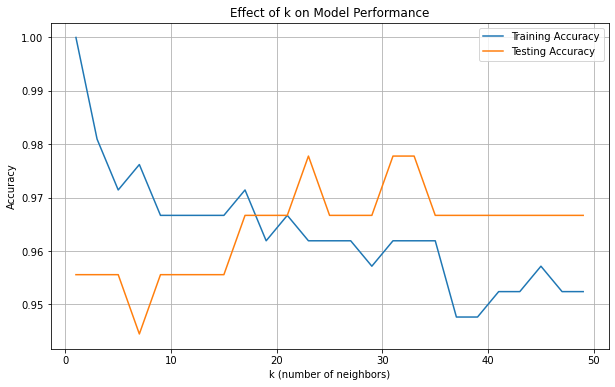

In [133]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_scores, label='Training Accuracy')
plt.plot(k_range, test_scores, label='Testing Accuracy')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('Effect of k on Model Performance')
plt.legend()
plt.grid(True)
plt.show()

In [204]:
def plot_knn_prediction(X_train, y_train, test_point, k):
    plt.figure(figsize=(20, 20))
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', alpha=0.7)
    plt.scatter(test_point[0], test_point[1], color='red', s=100, marker='*', label='Test Point')
    
    # Calculate distances
    distances = np.sqrt(np.sum((X_train - test_point)**2, axis=1))
    nearest_neighbor_idx = np.argsort(distances)[:k]
    
    # Plot circles around k nearest neighbors
    for idx in nearest_neighbor_idx:
        circle = plt.Circle((X_train[idx, 0], X_train[idx, 1]), 
                          radius=distances[idx], 
                          fill=False, 
                          linestyle='--', 
                          color='gray')
        plt.gca().add_artist(circle)
        
    plt.scatter(X_train[nearest_neighbor_idx, 0], 
               X_train[nearest_neighbor_idx, 1], 
               s=100, 
               alpha=0.5, 
               color='yellow', 
               label=f'{k} Nearest Neighbors')
    
    plt.title(f'KNN Prediction Visualization (k={k})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()

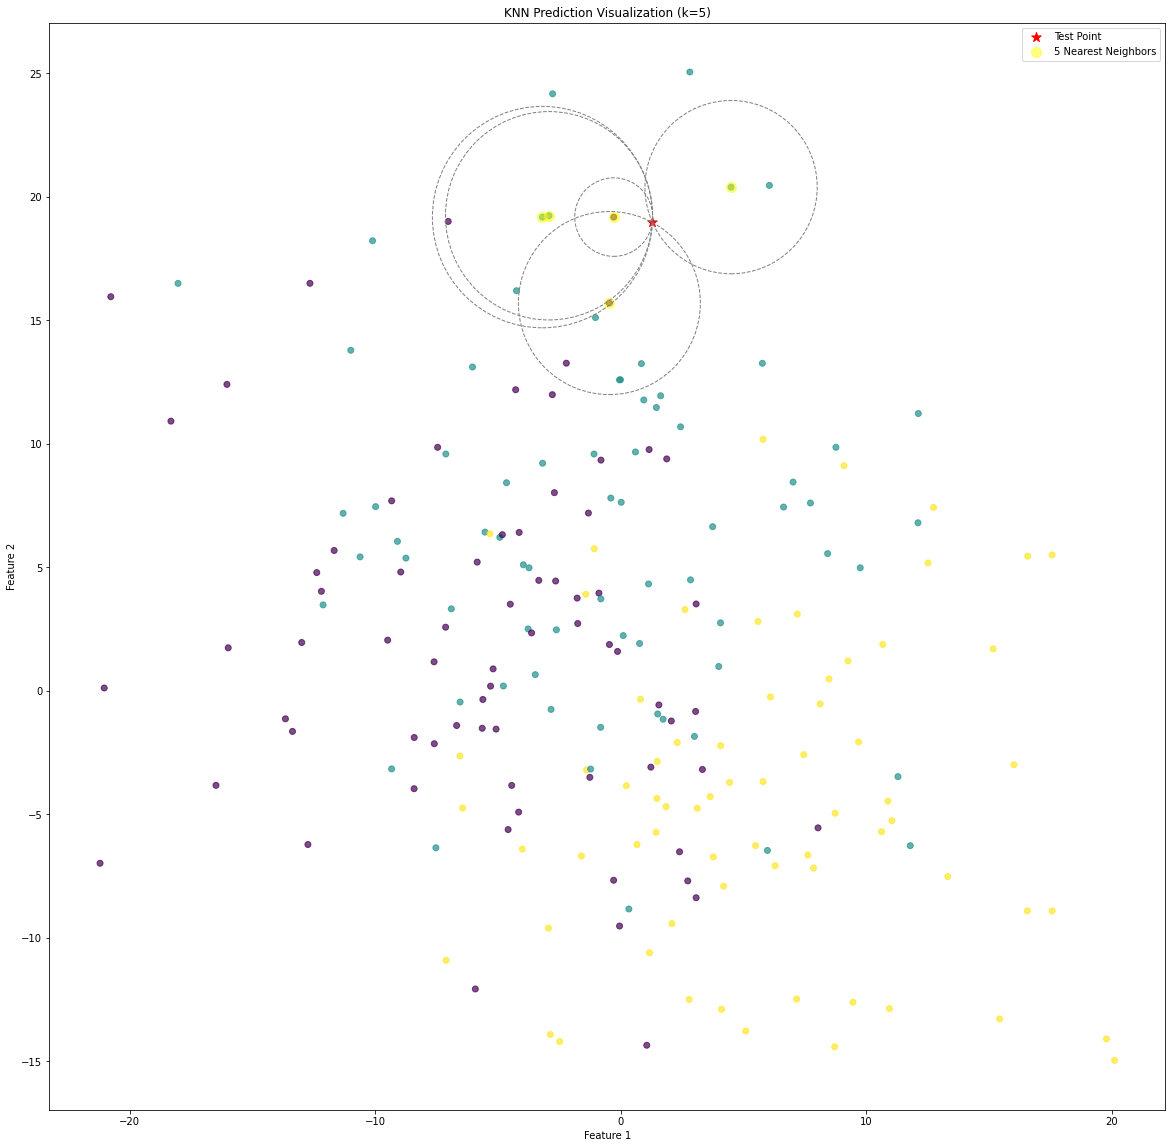

In [143]:
test_point = X_test[23]
plot_knn_prediction(X_train, y_train, test_point, k=5)

<Figure size 1080x360 with 0 Axes>

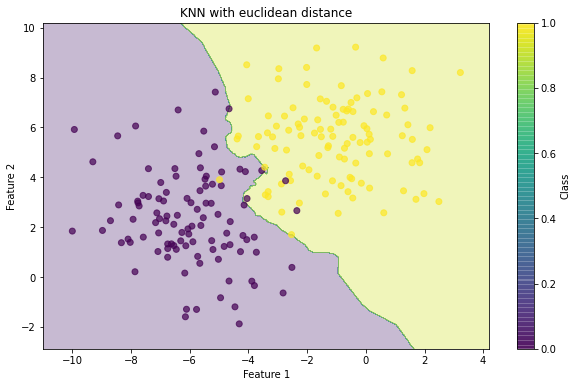

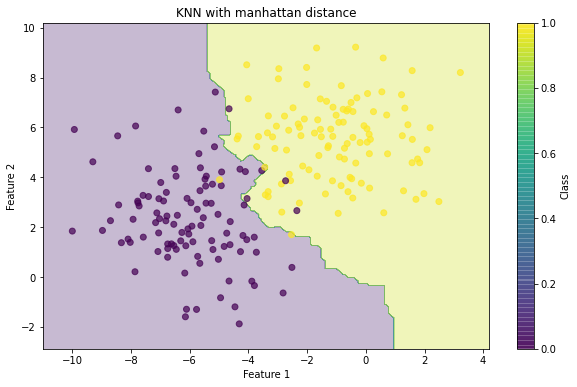

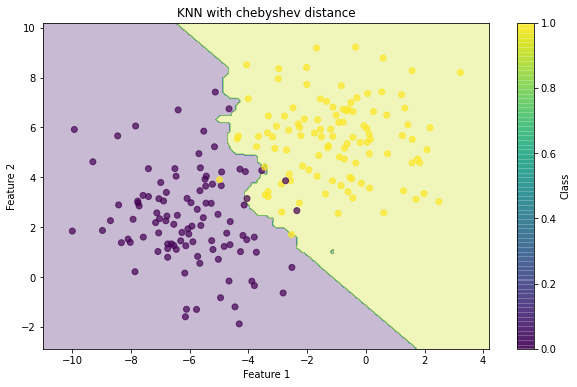

In [46]:
distance_metrics = ['euclidean', 'manhattan', 'chebyshev']
plt.figure(figsize=(15, 5))

for i, metric in enumerate(distance_metrics, 1):
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn.fit(X_train, y_train)
    
    plot_decision_boundary(X_train, y_train, knn, f'KNN with {metric} distance')

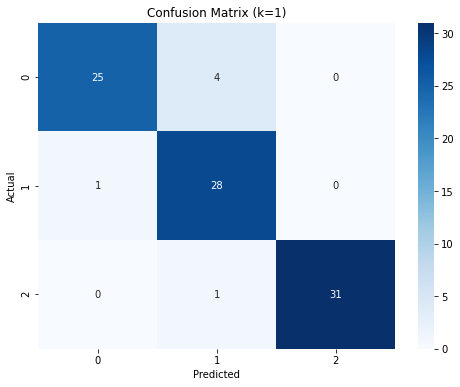

In [205]:
best_k = k_range[np.argmax(test_scores)]
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (k={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Logistic Regression

In [206]:
from sklearn.linear_model import LogisticRegression

In [207]:
X, y = make_blobs(n_samples=300, centers=2, cluster_std=1.8, random_state=1234)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)

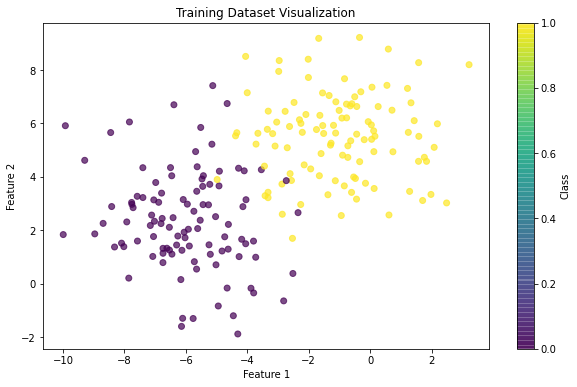

In [208]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.title('Training Dataset Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')
plt.show()

In [209]:
log_reg = LogisticRegression(random_state=1234)
log_reg.fit(X_train, y_train)


LogisticRegression(random_state=1234)

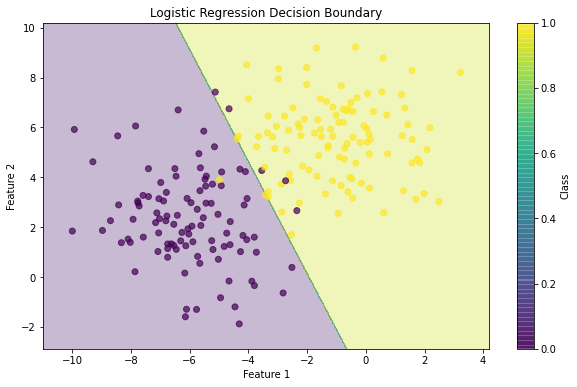

Wall time: 354 ms


In [212]:
%%time
plot_decision_boundary(X_train, y_train, log_reg, 'Logistic Regression Decision Boundary')

In [213]:
def plot_probability_contours(X, y, model, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, levels=np.linspace(0, 1, 11), cmap='RdYlBu', alpha=0.7)
    plt.colorbar(label='Probability of Class 1')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

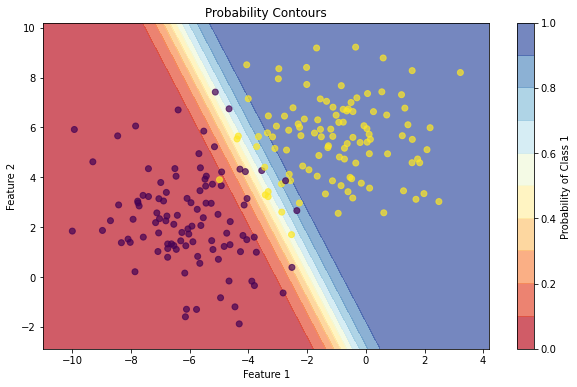

In [214]:
plot_probability_contours(X_train, y_train, log_reg, 'Probability Contours')

In [215]:
def plot_logistic_line(X, y, model):
    plt.figure(figsize=(10, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)
    
    # Plot decision boundary
    coef = model.coef_[0]
    intercept = model.intercept_[0]
    x_bounds = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1])
    y_bounds = -(coef[0] * x_bounds + intercept) / coef[1]
    
    plt.plot(x_bounds, y_bounds, 'r-', label='Decision Boundary')
    plt.arrow(0, 0, coef[0], coef[1], color='green', head_width=0.1, 
             head_length=0.1, label='Weight Vector')
    
    plt.title('Decision Boundary and Weight Vector')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid()
    plt.legend()
    plt.show()

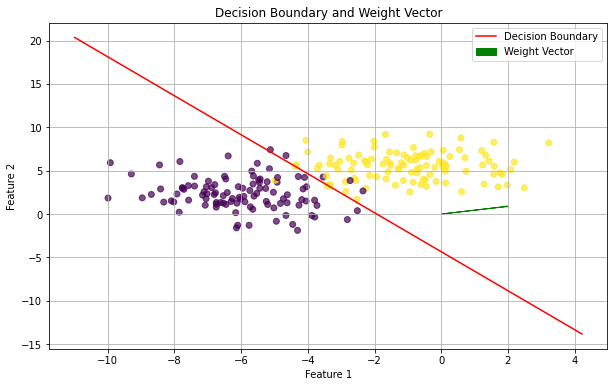

In [216]:
plot_logistic_line(X_train, y_train, log_reg)

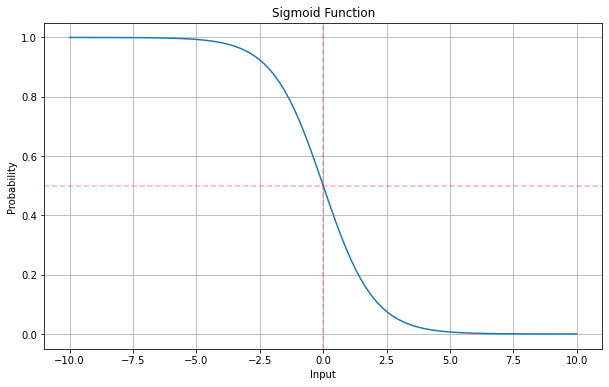

In [217]:
def sigmoid(x):
    return 1 / (1 + np.exp(x))

x = np.linspace(-10, 10, 100)
plt.figure(figsize=(10, 6))
plt.plot(x, sigmoid(x))
plt.title('Sigmoid Function')
plt.xlabel('Input')
plt.ylabel('Probability')
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.3)
plt.show()

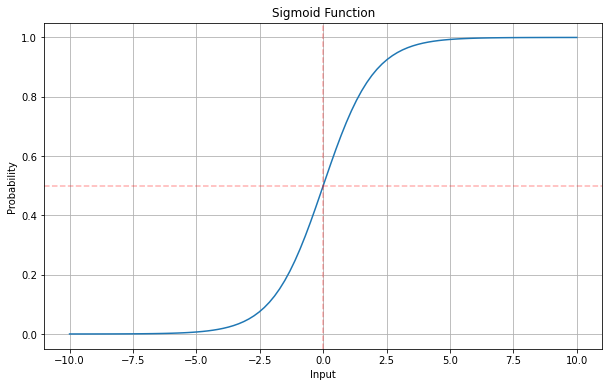

In [218]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
plt.figure(figsize=(10, 6))
plt.plot(x, sigmoid(x))
plt.title('Sigmoid Function')
plt.xlabel('Input')
plt.ylabel('Probability')
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.3)
plt.show()

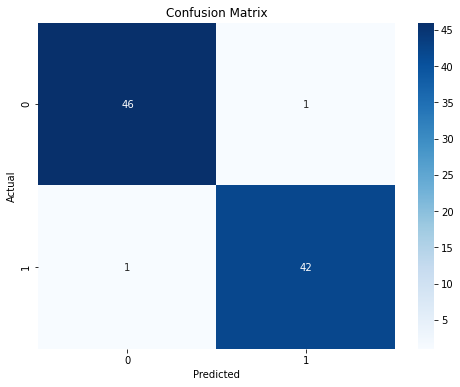

In [219]:
y_pred = log_reg.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Text(0.5, 1.0, 'Circle Classification Dataset')

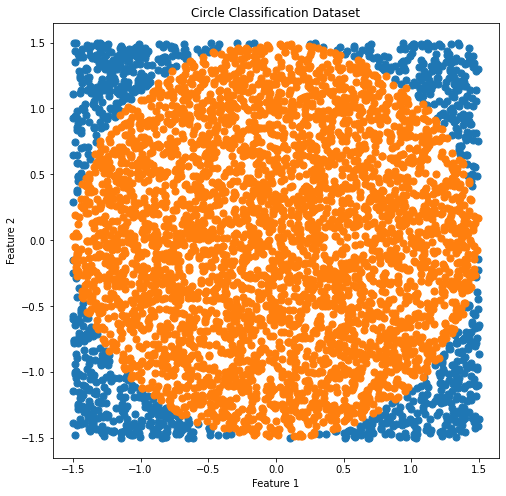

In [220]:
def make_circle_dataset(n_samples=100, radius=2.0, noise=0.1, random_state=None):
    np.random.seed(random_state)
    
    X = np.random.rand(n_samples, 2) * radius * 2 - radius
    
    y = (np.sqrt(X[:, 0]**2 + X[:, 1]**2) < radius).astype(int)
    
    X += np.random.normal(scale=noise, size=X.shape)
    
    return X, y

X, y = make_circle_dataset(n_samples=5000, radius=1.5, noise=0, random_state=42)

# Plot the dataset
plt.figure(figsize=(8, 8))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Class 0', s=50)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Class 1', s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Circle Classification Dataset')




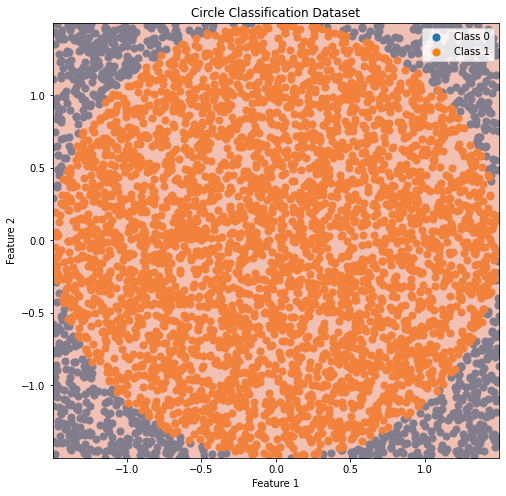

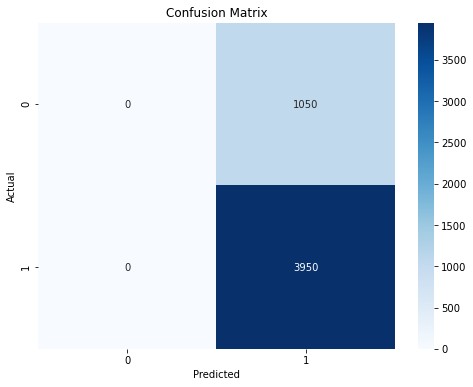

0.79

In [221]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Function to generate a circle dataset
def make_circle_dataset(n_samples=100, radius=2.0, noise=0.1, random_state=None):
    np.random.seed(random_state)
    
    # Generate random data points
    X = np.random.rand(n_samples, 2) * radius * 2 - radius
    
    # Create labels based on whether points fall inside the circle
    y = (np.sqrt(X[:, 0]**2 + X[:, 1]**2) < radius).astype(int)
    
    # Add some noise to the data points
    X += np.random.normal(scale=noise, size=X.shape)
    
    return X, y

# Generate the circle dataset
X, y = make_circle_dataset(n_samples=5000, radius=1.5, noise=0, random_state=42)

clf = LogisticRegression()
clf.fit(X, y)

# Plot the dataset
plt.figure(figsize=(8, 8))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Class 0', s=50)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Class 1', s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Circle Classification Dataset')

x_min, x_max = np.min(X[:, 0]), np.max(X[:, 0])
y_min, y_max = np.min(X[:, 1]), np.max(X[:, 1])
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
# Z = np.ones(Z.shape[0])
Z1 = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z1, cmap=plt.cm.RdBu, alpha=0.5)



plt.legend()
plt.show()

y_pred = clf.predict(X)
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

accuracy_score(y, y_pred)


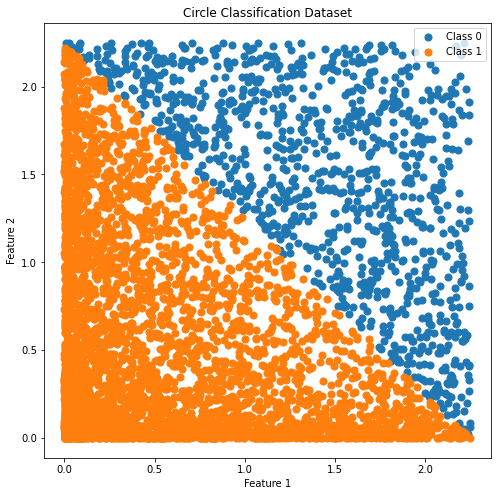

In [222]:
plt.figure(figsize=(8, 8))
plt.scatter(X[y == 0][:, 0]**2, X[y == 0][:, 1]**2, label='Class 0', s=50)
plt.scatter(X[y == 1][:, 0]**2, X[y == 1][:, 1]**2, label='Class 1', s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Circle Classification Dataset')
plt.legend()
plt.show()

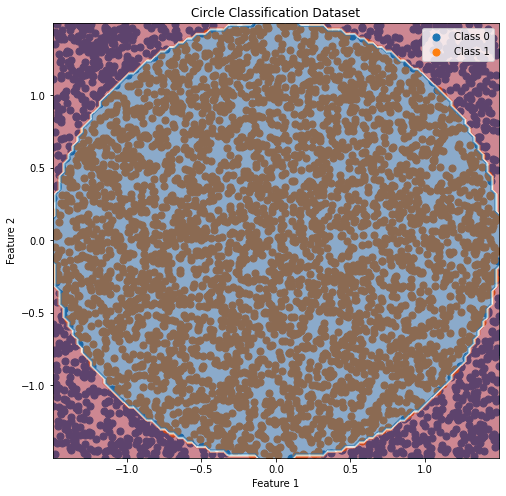

7787 10000


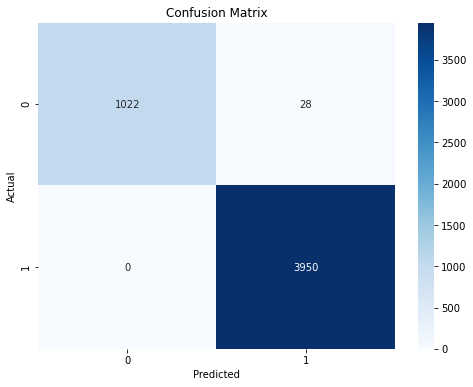

0.9944

In [223]:
clf = LogisticRegression()
clf.fit(X**2, y)

# Plot the dataset
plt.figure(figsize=(8, 8))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Class 0', s=50)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Class 1', s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Circle Classification Dataset')

x_min, x_max = np.min(X[:, 0]), np.max(X[:, 0])
y_min, y_max = np.min(X[:, 1]), np.max(X[:, 1])
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = clf.predict(np.c_[xx.ravel()**2, yy.ravel()**2])
# Z = np.ones(Z.shape[0])
Z1 = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z1, cmap=plt.cm.RdBu, alpha=0.5)



plt.legend()
plt.show()

print(sum(Z),len(Z))


y_pred = clf.predict(X**2)
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

accuracy_score(y, y_pred)


array([1.49405737e-06, 9.99998506e-01])

In [224]:
clf.coef_, clf.intercept_

(array([[-10.36458355, -10.39947836]]), array([23.57457634]))

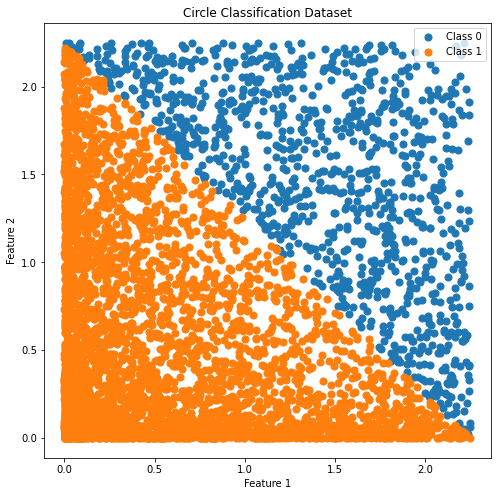

In [225]:
plt.figure(figsize=(8, 8))
plt.scatter(X[y == 0][:, 0]**2, X[y == 0][:, 1]**2, label='Class 0', s=50)
plt.scatter(X[y == 1][:, 0]**2, X[y == 1][:, 1]**2, label='Class 1', s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Circle Classification Dataset')
plt.legend()
plt.show()

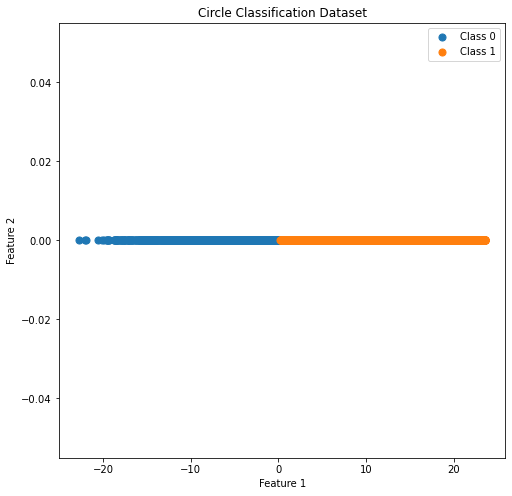

In [226]:
new_x =  np.dot(X**2, clf.coef_.T) + clf.intercept_
plt.figure(figsize=(8, 8))
plt.scatter(new_x[y == 0], np.zeros(new_x[y == 0].shape[0]), label='Class 0', s=50)
plt.scatter(new_x[y == 1], np.zeros(new_x[y == 1].shape[0]), label='Class 1', s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Circle Classification Dataset')
plt.legend()
plt.show()

In [227]:
clf = LogisticRegression()
clf.fit(X, y)

LogisticRegression()

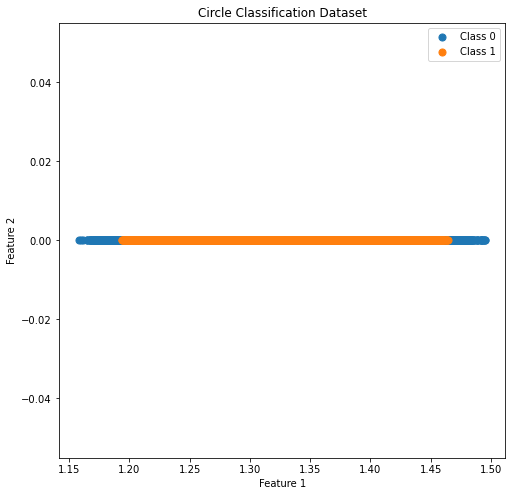

In [228]:
new_x =  np.dot(X, clf.coef_.T) + clf.intercept_
plt.figure(figsize=(8, 8))
plt.scatter(new_x[y == 0], np.zeros(new_x[y == 0].shape[0]), label='Class 0', s=50)
plt.scatter(new_x[y == 1], np.zeros(new_x[y == 1].shape[0]), label='Class 1', s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Circle Classification Dataset')
plt.legend()
plt.show()


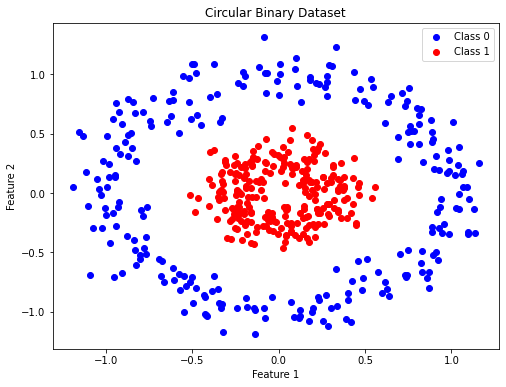

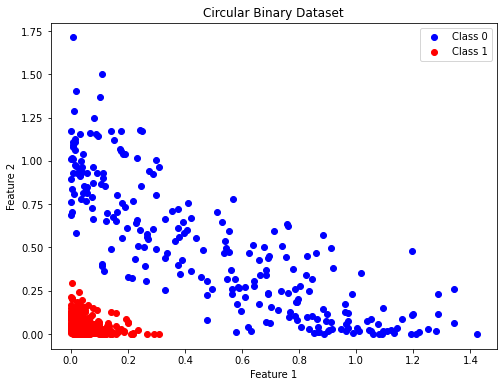

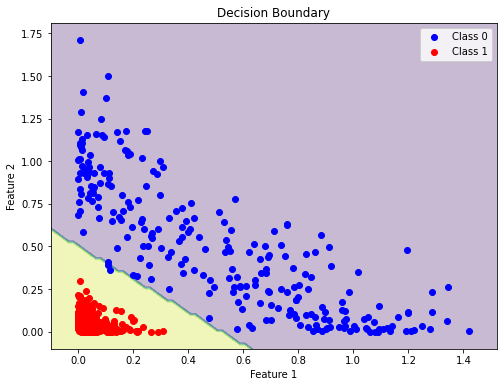

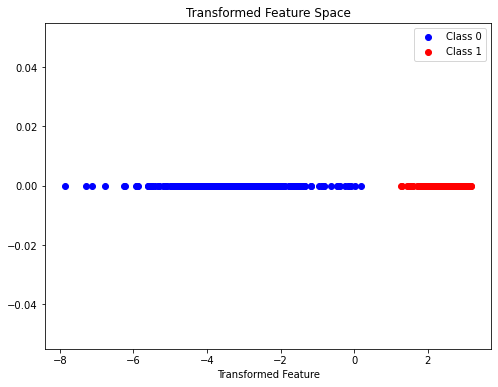

In [110]:
from sklearn.datasets import make_circles

# Generate circular binary dataset
X, y = make_circles(n_samples=500, noise=0.1, factor=0.3, random_state=42)


# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Class 1')
plt.title('Circular Binary Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

X = X**2

plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Class 1')
plt.title('Circular Binary Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# Logistic Regression
model = LogisticRegression()
model.fit(X, y)

# Visualize the decision boundary
x1_min, x1_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
x2_min, x2_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))
Z = model.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx1, xx2, Z, alpha=0.3)
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Class 1')
plt.title('Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()



transformed_X = np.dot(X, model.coef_.T) + model.intercept_

# Visualize the transformed space
plt.figure(figsize=(8, 6))
plt.scatter(transformed_X[y == 0], np.zeros(sum(y == 0)), color='blue', label='Class 0')
plt.scatter(transformed_X[y == 1], np.zeros(sum(y == 1)), color='red', label='Class 1')
plt.title('Transformed Feature Space')
plt.xlabel('Transformed Feature')
plt.legend()
plt.show()